In [1]:
import numpy as np
import pandas as pd

In [2]:
data = pd.read_csv("train.csv")

In [3]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
data.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [6]:
data= data.dropna()

In [7]:
data.isna().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   int64  
 1   Order ID       9789 non-null   object 
 2   Order Date     9789 non-null   object 
 3   Ship Date      9789 non-null   object 
 4   Ship Mode      9789 non-null   object 
 5   Customer ID    9789 non-null   object 
 6   Customer Name  9789 non-null   object 
 7   Segment        9789 non-null   object 
 8   Country        9789 non-null   object 
 9   City           9789 non-null   object 
 10  State          9789 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   object 
 13  Product ID     9789 non-null   object 
 14  Category       9789 non-null   object 
 15  Sub-Category   9789 non-null   object 
 16  Product Name   9789 non-null   object 
 17  Sales          9789 non-null   float64
dtypes: float64(2)

In [9]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='%d/%m/%Y')
data['Ship Date'] = pd.to_datetime(data['Ship Date'], format='%d/%m/%Y')

# Convert 'Postal Code' to int. First, fill any NaN values with 0
data['Postal Code'] = data['Postal Code'].fillna(0).astype(int)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   int64         
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

### Handling Outliers using IQR method for 'Sales' column

In [11]:
# Calculate Q1, Q3, and IQR for the 'Sales' column
Q1 = data['Sales'].quantile(0.25)
Q3 = data['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Define upper and lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Cap the outliers
data['Sales'] = np.where(data['Sales'] < lower_bound, lower_bound, data['Sales'])
data['Sales'] = np.where(data['Sales'] > upper_bound, upper_bound, data['Sales'])

print(f"Outliers in 'Sales' handled. Values below {lower_bound:.2f} were set to {lower_bound:.2f} and values above {upper_bound:.2f} were set to {upper_bound:.2f}.")

Outliers in 'Sales' handled. Values below -272.47 were set to -272.47 and values above 500.11 were set to 500.11.


In [12]:
# Display descriptive statistics after outlier handling
display(data['Sales'].describe())

,Sales
count,9789.000000
mean,140.614676
std,169.301036
min,0.444000
25%,17.248000
50%,54.384000
75%,210.392000
max,500.108000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   object        
 5   Customer ID    9789 non-null   object        
 6   Customer Name  9789 non-null   object        
 7   Segment        9789 non-null   object        
 8   Country        9789 non-null   object        
 9   City           9789 non-null   object        
 10  State          9789 non-null   object        
 11  Postal Code    9789 non-null   int64         
 12  Region         9789 non-null   object        
 13  Product ID     9789 non-null   object        
 14  Category       9789 non-null   object        
 15  Sub-Category   9789 non-nu

In [19]:
data['Sales'].describe()


,Sales
count,9789.000000
mean,140.614676
std,169.301036
min,0.444000
25%,17.248000
50%,54.384000
75%,210.392000
max,500.108000


### Histogram Plots for Numerical Columns

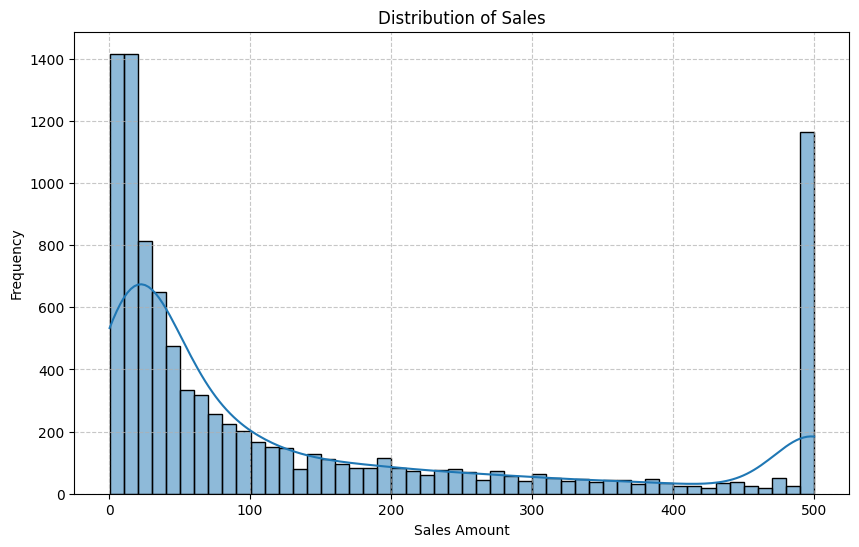

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for 'Sales' column
plt.figure(figsize=(10, 6))
sns.histplot(data['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Bar Charts for Categorical Columns

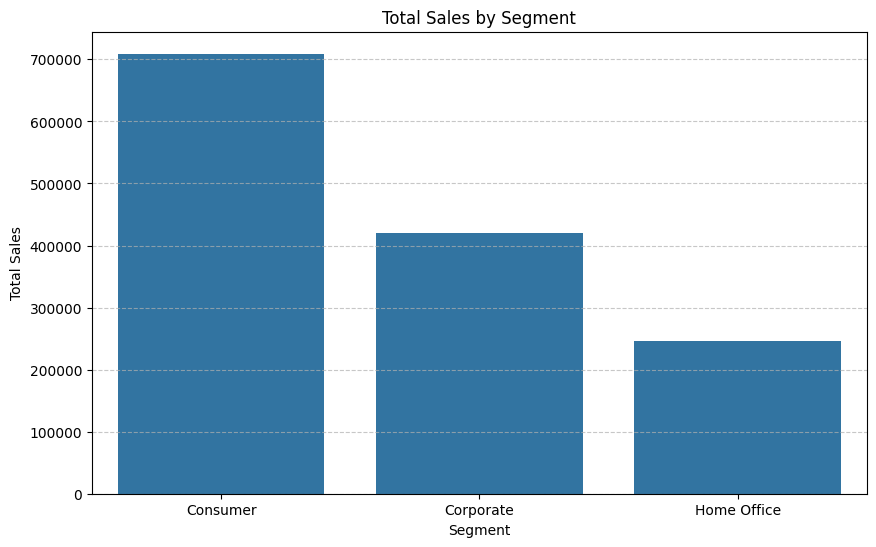

In [20]:
# Bar chart for Sales by Segment
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Sales', data=data.groupby('Segment')['Sales'].sum().reset_index())
plt.title('Total Sales by Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

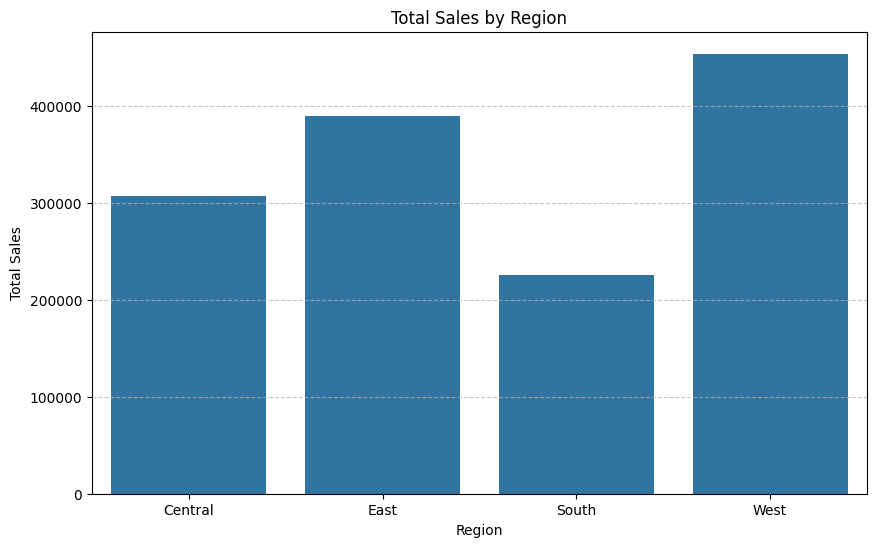

In [21]:
# Bar chart for Sales by Region
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales', data=data.groupby('Region')['Sales'].sum().reset_index())
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

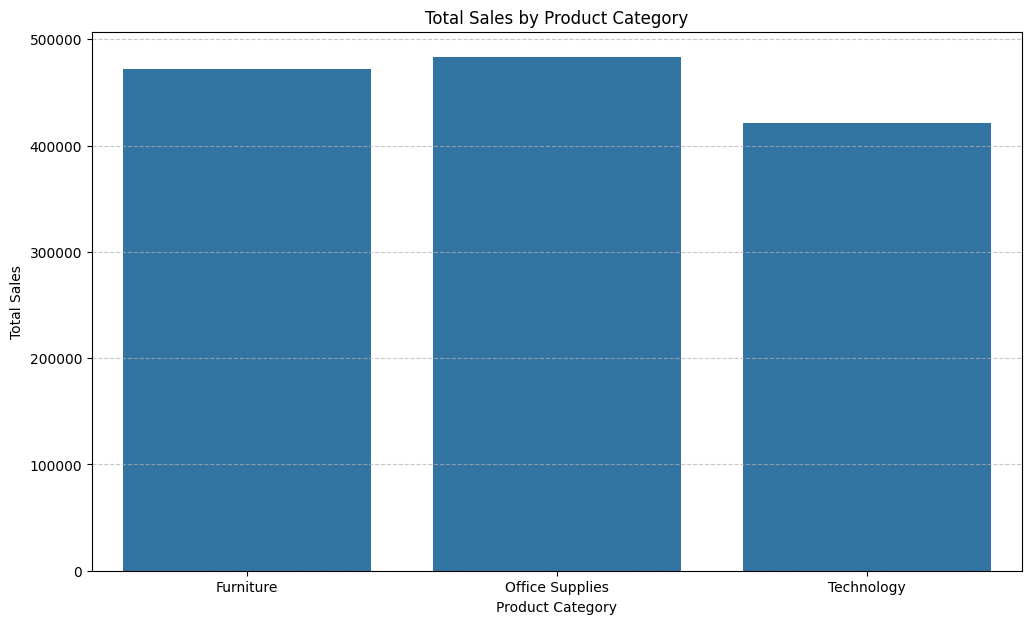

In [24]:
# Bar chart for Sales by Category
plt.figure(figsize=(12, 7))
sns.barplot(x='Category', y='Sales', data=data.groupby('Category')['Sales'].sum().reset_index())
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Axes: >

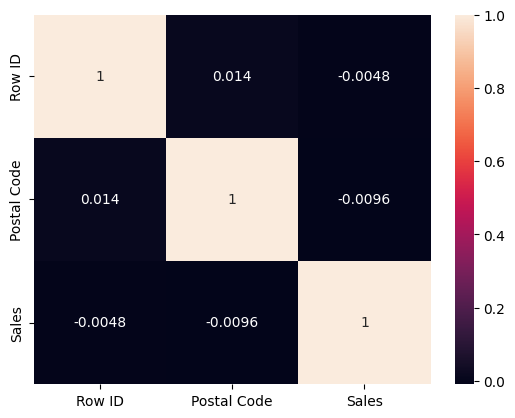

In [27]:
sns.heatmap(data.corr(numeric_only = True),annot =True)

### Line Chart for Sales Trend Over Time

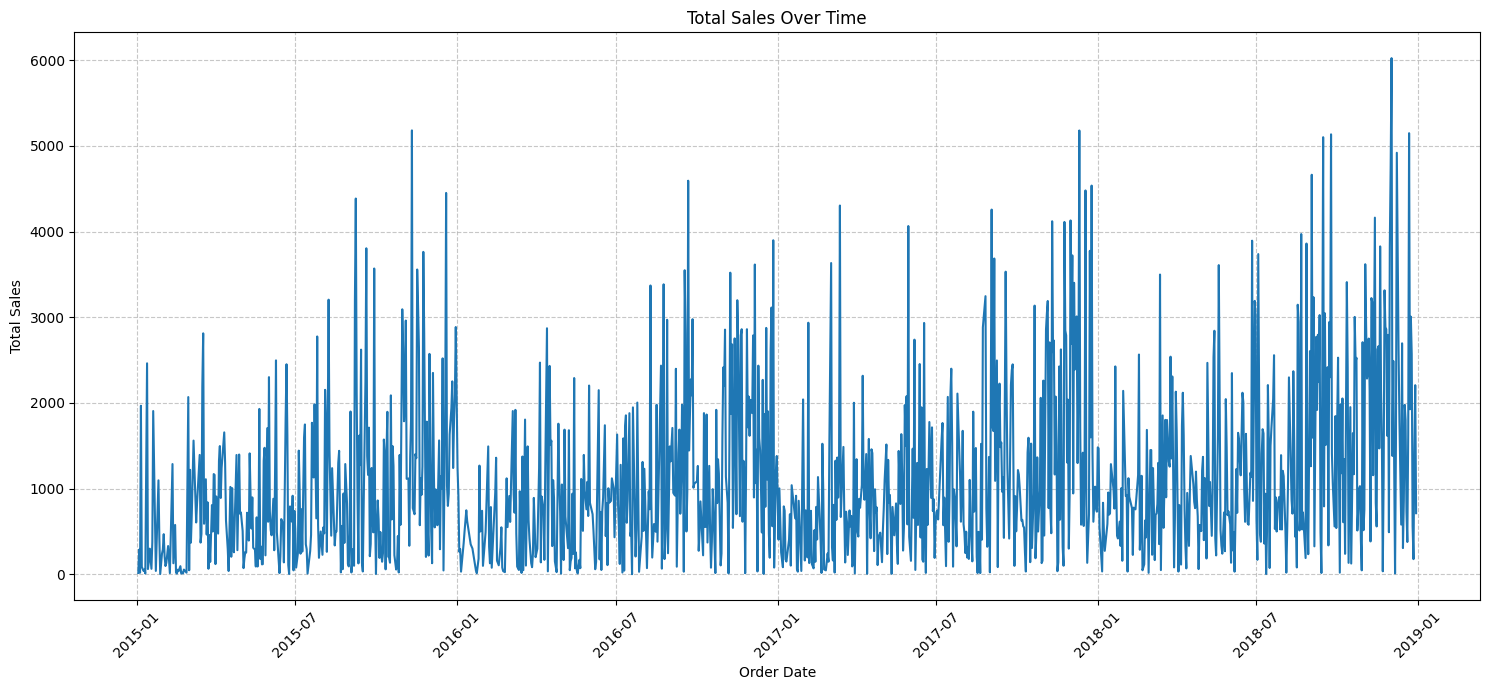

In [30]:
# Group sales by Order Date and sum them up
daily_sales = data.groupby('Order Date')['Sales'].sum().reset_index()

# Plotting the line chart
plt.figure(figsize=(15, 7))
sns.lineplot(x='Order Date', y='Sales', data=daily_sales)
plt.title('Total Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Insights from Data Analysis

Based on the data cleaning, outlier handling, and visualizations, here are 5 key insights:

1.  **Data Completeness and Type Conversion:** Initially, there were a few missing values in 'Postal Code', which were addressed by dropping the rows. Crucially, 'Order Date' and 'Ship Date' were successfully converted to datetime objects, and 'Postal Code' was converted to an integer, ensuring data integrity for further analysis.

2.  **Sales Distribution and Outlier Management:** The 'Sales' data initially contained significant outliers. After applying the IQR method to cap these outliers, the sales distribution is now better represented, although still positively skewed, indicating that a majority of transactions involve smaller sales amounts.

3.  **Customer Segment Performance:** The 'Consumer' segment consistently accounts for the highest total sales, significantly outperforming the 'Corporate' and 'Home Office' segments. This suggests that marketing and sales strategies should heavily focus on the consumer base.

4.  **Regional Sales Disparity:** Sales are heavily concentrated in the 'West' and 'East' regions, which generate substantially more revenue than the 'Central' and 'South' regions. This highlights potential opportunities for growth and targeted campaigns in underperforming regions.

5.  **Product Category Contributions:** 'Office Supplies' and 'Furniture' are the leading product categories in terms of total sales, closely followed by 'Technology'. This distribution indicates strong demand across these core categories, with a slight edge to Office Supplies and Furniture.